## Form factor integration approach study
This notebook will hold some methods to evaluate different approaches for the integration of form factors

In [29]:
from examples.utils.trace_integration import integration_test as intt
import numpy as np
import matplotlib.pyplot as plt

In [30]:
integration = intt(ww=1, hh=1, ll=1, gtype="b")

In [31]:
def plotting_options(in_dict):
    options = {"color": None, "line": None, "marker": ""}

    match in_dict["method"]:
        case "contour":
            options["line"] = "solid"
        case "naive":
            options["line"] = "dashed"
        case "nusselt":
            options["line"] = "dotted"

    if in_dict["int1"] == "analytical":
        options["line"] = "-."

    match in_dict["int2"]:
        case "random":
            options["color"] = "forestgreen"
        case "regular":
            options["color"] = "navy"
        case "poly_NC":
            options["color"] = "firebrick"
        case "poly_GL":
            options["color"] = "coral"

    return options

In [32]:
order_arr = np.arange(1, 6)
out = []
for method in ["naive", "contour"]:
    if method == "contour":
        opp1 = ["analytical", "poly_GL", "poly_NC"]
    else:
        opp1 = ["regular", "random", "poly_NC", "poly_GL"]

    for op1 in opp1:
        if op1 == "analytical":
            opp2 = ["poly_GL", "poly_NC"]
        else:
            opp2 = [op1]

        for op2 in opp2:
            if op2 == "poly_GL" or op2 == "poly_NC":
                oorder = order_arr[order_arr < 4]
            else:
                oorder = order_arr

            out.append(
                {
                    "method": method,
                    "int1": op1,
                    "int2": op2,
                    "order": [],
                    "runtime": [],
                    "memory": [],
                    "rel_error": [],
                },
            )

            for poly_order in oorder:
                integration.set_poly_order(poly_order)
                integration.set_int_method(op1=method, op2=op1, op3=op2)
                integration.print_stats()
                tim = integration.integrate(trace_time=True, n=100)
                integration.print_results()
                err = integration.error
                mem = integration.integrate(trace_mem=True)

                out[-1]["order"].append(poly_order)
                out[-1]["runtime"].append(tim * 1000)
                out[-1]["memory"].append(mem / 1000)
                out[-1]["rel_error"].append(np.abs((err - 1) * 100))



############################################
Form Factor approach: naive
Integral approach: regular
# of samples in each patch: 4

 -> relative ff error:       31.9942%
 -> gain per 100 bounces:      120.6dB



############################################
Form Factor approach: naive
Integral approach: regular
# of samples in each patch: 9

 -> relative ff error:       21.7558%
 -> gain per 100 bounces:      85.5dB



############################################
Form Factor approach: naive
Integral approach: regular
# of samples in each patch: 16

 -> relative ff error:       16.4704%
 -> gain per 100 bounces:      66.2dB



############################################
Form Factor approach: naive
Integral approach: regular
# of samples in each patch: 25

 -> relative ff error:       13.2490%
 -> gain per 100 bounces:      54.0dB



############################################
Form Factor approach: naive
Integral approach: regular
# of samples in each patch: 36

 -> relative ff error: 

C:\Users\jotag\Documents\dev\sparrowpy\sparrowpy\form_factor\integration.py:327: RuntimeWarning: divide by zero encountered in log
  form_mat[i][j] = np.log(



 -> relative ff error:       inf%
 -> gain per 100 bounces:      infdB



############################################
Form Factor approach: contour
Internal integral approach: poly_GL
External integral approach: poly_GL
Polynomial order: 2

 -> relative ff error:       inf%
 -> gain per 100 bounces:      infdB



############################################
Form Factor approach: contour
Internal integral approach: poly_GL
External integral approach: poly_GL
Polynomial order: 3

 -> relative ff error:       inf%
 -> gain per 100 bounces:      infdB



############################################
Form Factor approach: contour
Internal integral approach: poly_NC
External integral approach: poly_NC
Polynomial order: 1

 -> relative ff error:       inf%
 -> gain per 100 bounces:      infdB



############################################
Form Factor approach: contour
Internal integral approach: poly_NC
External integral approach: poly_NC
Polynomial order: 2

 -> relative ff error:       in

C:\Users\jotag\Documents\dev\sparrowpy\sparrowpy\form_factor\integration.py:136: RuntimeWarning: invalid value encountered in scalar multiply
  out -= c[i] * x[0] ** (len(c) - i) / (len(c) - i)
C:\Users\jotag\Documents\dev\sparrowpy\sparrowpy\form_factor\integration.py:135: RuntimeWarning: invalid value encountered in scalar multiply
  out += c[i] * x[-1] ** (len(c) - i) / (len(c) - i)



 -> relative ff error:       nan%
 -> gain per 100 bounces:      nandB



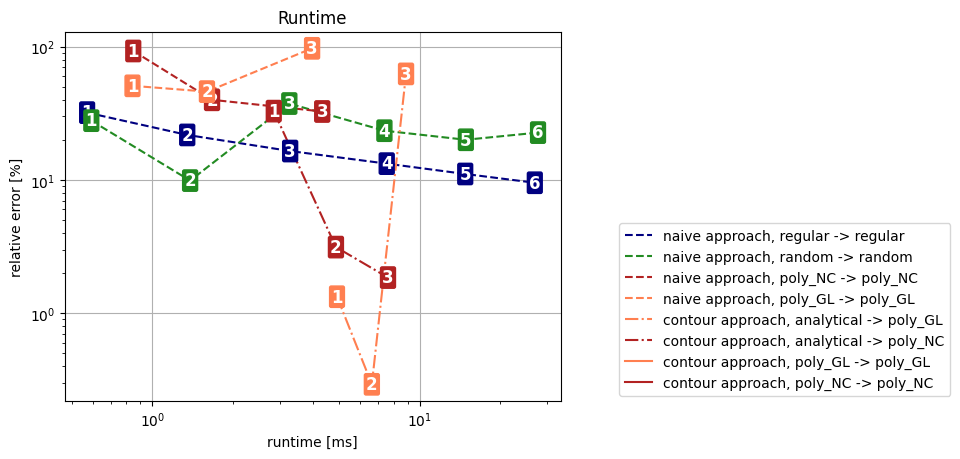

In [41]:
plt.figure()
for entry in out:
    options = plotting_options(entry)
    plt.loglog(
        entry["runtime"],
        entry["rel_error"],
        linestyle=options["line"],
        marker=options["marker"],
        color=options["color"],
        label=f"{entry['method']} approach, {entry['int1']} -> {entry['int2']}",
    )
    for i, (x, y) in enumerate(zip(entry["runtime"], entry["rel_error"])):
        plt.text(
            x,
            y,
            entry["order"][i],
            horizontalalignment="center",
            verticalalignment="center",
            color="white",
            bbox={
                "facecolor": options["color"],
                "edgecolor": options["color"],
                "boxstyle": "round",
                "pad": 0.1,
            },
            weight="bold",
            fontsize=12,
        )

plt.xlabel("runtime [ms]")
plt.ylabel("relative error [%]")
plt.title("Runtime")
plt.legend(bbox_to_anchor=(1.8, 0.5))
plt.grid()
plt.show()


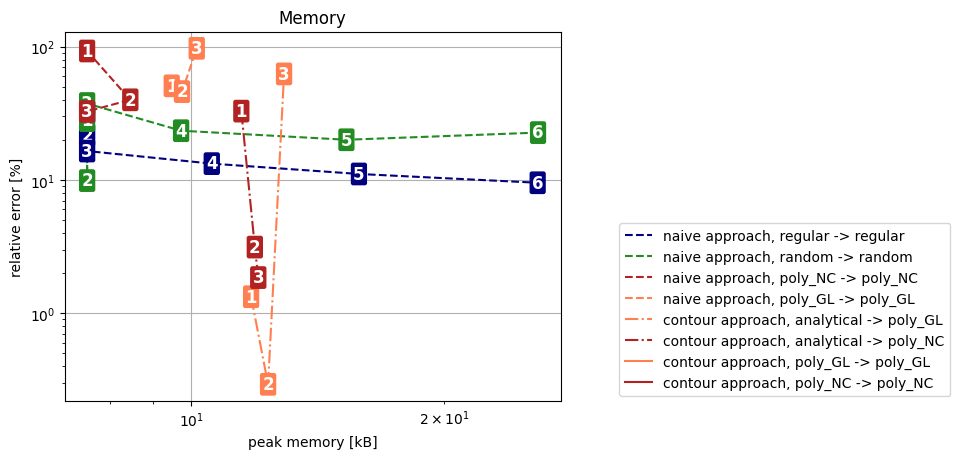

In [43]:
plt.figure()
for entry in out:
    options = plotting_options(entry)
    plt.loglog(
        entry["memory"],
        entry["rel_error"],
        linestyle=options["line"],
        marker=options["marker"],
        color=options["color"],
        label=f"{entry['method']} approach, {entry['int1']} -> {entry['int2']}",
    )
    for i, (x, y) in enumerate(zip(entry["memory"], entry["rel_error"])):
        plt.text(
            x,
            y,
            entry["order"][i],
            horizontalalignment="center",
            verticalalignment="center",
            color="white",
            bbox={
                "facecolor": options["color"],
                "edgecolor": options["color"],
                "boxstyle": "round",
                "pad": 0.1,
            },
            weight="bold",
            fontsize=12,
        )
plt.xlabel("peak memory [kB]")
plt.ylabel("relative error [%]")
plt.title("Memory")
plt.legend(bbox_to_anchor=(1.8, 0.5))
plt.grid()
plt.show()